(1989, 13)
                id         Open         High          Low        Close  \
count  1989.000000  1989.000000  1989.000000  1989.000000  1989.000000   
mean    994.000000   240.565849   241.768182   239.240695   240.599327   
std     574.319162    75.764185    76.131061    75.334142    75.769753   
min       0.000000   141.968372   142.601941   141.099250   141.472900   
25%     497.000000   175.159842   175.844948   174.447877   175.229828   
50%     994.000000   229.835653   232.273885   227.302794   230.052475   
75%    1491.000000   272.524491   273.384360   271.473095   272.542542   
max    1988.000000   444.234977   445.146803   440.409036   442.514648   

             Volume  feature_ret_1d  feature_ret_5d  feature_sma_20_ratio  \
count  1.989000e+03     1989.000000     1989.000000           1989.000000   
mean   9.367154e+07        0.000616        0.003002              0.005312   
std    4.973862e+07        0.010741        0.021759              0.023632   
min    2.02700

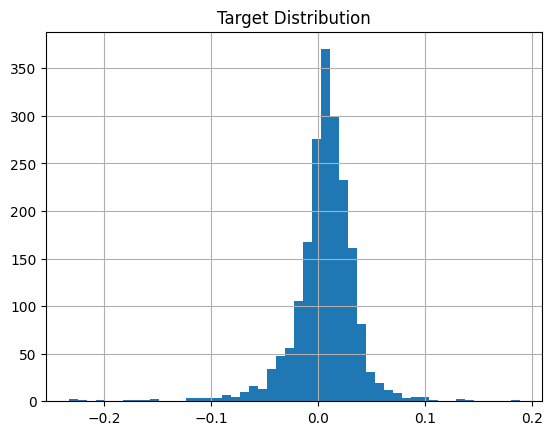

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train copy.csv')
test = pd.read_csv('test copy.csv')

print(train.shape)
print(train.describe())
print(train.isnull().sum())

# Target distribution
train['target'].hist(bins=50)
plt.title('Target Distribution')
plt.show()

In [2]:
target_col = 'target'
id_col = 'id'
feature_cols = [c for c in train.columns if c not in [target_col, id_col]]

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]


In [3]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline


model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])
feature_cols = [
    col for col in train.columns
    if col not in ['target', 'Date']
]
X_train = train[feature_cols]
y_train = train['target']

X_test = test[feature_cols]


tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(X_train):
    model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    val_pred = model.predict(X_train.iloc[val_idx])
    print(f"Fold R²: {r2_score(y_train.iloc[val_idx], val_pred):.4f}")

# After validation, fit on the full training data before predicting on test
model.fit(X_train, y_train)

Fold R²: -25.5570
Fold R²: -9.8956
Fold R²: -0.1800
Fold R²: 0.1114
Fold R²: -8.5224


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', XGBRegressor(
        n_estimators=100,
        max_depth= 3,
        learning_rate=0.05,
        random_state=42
    ))
])
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(X_train):
    model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    val_pred = model.predict(X_train.iloc[val_idx])
    print(f"Fold R²: {r2_score(y_train.iloc[val_idx], val_pred):.4f}")

# After validation, fit on the full training data before predicting on test
model.fit(X_train, y_train)

Fold R²: 0.2742
Fold R²: 0.3879
Fold R²: 0.4686
Fold R²: 0.5223
Fold R²: 0.5586


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

In [5]:
print(feature_cols)
model.named_steps['regressor'].feature_importances_

['id', 'Open', 'High', 'Low', 'Close', 'Volume', 'feature_ret_1d', 'feature_ret_5d', 'feature_sma_20_ratio', 'feature_vol_ratio_20d', 'feature_high_low_spread']


array([0.15738575, 0.20132338, 0.15136147, 0.08189347, 0.08960038,
       0.04039345, 0.03453806, 0.04217862, 0.10991599, 0.05156007,
       0.03984932], dtype=float32)

In [6]:
import numpy as np

importances = model.named_steps['regressor'].feature_importances_

feature_cols = np.array(X_train.columns)  

mask = importances >= 0.07

selected_features = feature_cols[mask]

X_selected = X_train[selected_features]

/var/folders/kn/kl279g297x13xb8j1_102bn80000gn/T/ipykernel_31986/2443913551.py:43: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test = X_test.fillna(method="ffill")


Fold R²: -0.0030
Fold R²: -12225619406176690176.0000
Fold R²: -173807501817055136.0000
Fold R²: -27841617425119871762432.0000
Fold R²: -27780242425682.4766


In [34]:
predictions = model.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'predicted_target': predictions
})
submission.to_csv('my_submission.csv', index=False)

In [39]:
# train['target'] = train['target'].pct_change()
# train['target'] = train['target'].replace([np.inf, -np.inf], np.nan)
# train = train.dropna(subset=['target']).reset_index(drop=True)
# train['target'] = train['target'].clip(-0.5, 0.5)

# df = train.copy()
# df["lag_1"] = df["target"].shift(1)
# df["lag_2"] = df["target"].shift(2)
# df["lag_3"] = df["target"].shift(3)
# df["rolling_mean_5"] = df["target"].rolling(5).mean()
# df["rolling_std_5"] = df["target"].rolling(5).std()
# df = df.dropna().reset_index(drop=True)

# feature_cols = [
#     col for col in df.columns
#     if col not in ['target', 'Date']
# ]
# X_train = df[feature_cols].copy()
# y_train = df['target'].copy()


# X_test = test.copy()
# tail_vals = y_train.tail(5).values

# X_test["lag_1"]          = tail_vals[-1] if len(tail_vals) >= 1 else 0
# X_test["lag_2"]          = tail_vals[-2] if len(tail_vals) >= 2 else 0
# X_test["lag_3"]          = tail_vals[-3] if len(tail_vals) >= 3 else 0
# X_test["rolling_mean_5"] = tail_vals.mean() if len(tail_vals) >= 1 else 0
# X_test["rolling_std_5"]  = tail_vals.std()  if len(tail_vals) >= 2 else 0

# X_test = X_test[feature_cols]

# model = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('regressor', XGBRegressor(
#         n_estimators=100,
#         max_depth=3,
#         learning_rate=0.05,
#         random_state=42,
#         seed=42
#     ))
# ])

# tscv = TimeSeriesSplit(n_splits=5)
# for train_idx, val_idx in tscv.split(X_train):
#     X_tr  = X_train.iloc[train_idx].copy()
#     X_val = X_train.iloc[val_idx].copy()
#     y_tr  = y_train.iloc[train_idx].copy()
#     y_val = y_train.iloc[val_idx].copy()
#     model.fit(X_tr, y_tr)
#     val_pred = model.predict(X_val)
#     print(f"Fold R²: {r2_score(y_val, val_pred):.4f}")

# model.fit(X_train, y_train)
# test_predictions = model.predict(X_test)

Fold R²: 0.2742
Fold R²: 0.3879
Fold R²: 0.4686
Fold R²: 0.5223
Fold R²: 0.5586


In [40]:
# okay so i firts tried with linear regression , clearly understanding that model gave the worst values of R2 , suggesting that the features are heavily interlinked  , so i had to use XGBoost it gave better values of r2 closer to 0 after tweaking some values for depth , max_samples , and i got the best possible for these values after that i tried to remove some features leading to an extreme bad r2 value , so i came to the conclusion that even if their values are less , they are important , then i tried using rolling mean and got these values . 

In [47]:
predictions = model.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'target': predictions
})
submission.to_csv('my_submission.csv', index=False)